# Backpropagation

Implementemos el algoritmo para entrenar la red neuronal, vimos en el notebook anterior como armar una red y pasarle información para procesar pero sin ningún tipo de ajuste. <br><br>
En particular vamos a estar armando un modelo que resuelva la compuerta lógica XOR.


### SETUP

In [14]:
!pip install numpy==1.26.4
!pip install matplotlib==3.5.2

import numpy as np
import matplotlib.pyplot as plt

## Creación de la Red

Primero definimos los parametros de nuestro modelo, en particular los inputs y outputs esperados para la compuerta lógica XOR, el tamaño de la red neuronal junto a pesos/bias al azar, el learning rate y epochs (o iteraciones) de entrenamiento.

In [15]:
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]]).T  
output = np.array([0, 1, 1, 0])

inputSize = 2      # Cantidad de nodos en capa de entrada
hiddenSize = 2     # Cantidad de nodos en capa intermedia
outputSize = 1     # Cantidad de nodos en capa de salida

learning_rate = 0.1
epochs = 200000


w1 = np.random.rand(hiddenSize, inputSize) * 2 - 1  # Peso de aristas Entrada -> Intermedia
b1 = np.random.rand(hiddenSize, 1) * 2 - 1          # Bias para capa intermedia
w2 = np.random.rand(outputSize, hiddenSize) * 2 - 1 # Peso de aristas Intermedia -> Salida
b2 = np.random.rand(outputSize, 1) * 2 - 1          # Bias para capa de salida


## Entrenamiento 

Ahora apliquemos los [pasos de entrenamiento](README.md) a nuestra red para optimizar el error que comete en las predicciones, además guardemos el error cada 500 iteraciones para visualizar la curva de aprendizaje.

In [16]:
error_list = []
for epoch in range(epochs):
    # Forward propagation
    z1 = np.dot(w1, X) + b1  # Producto vectorial + bias (para capa intermedia)
    a1 = 1 / (1 + np.exp(-z1))  # Función de activación 

    z2 = np.dot(w2, a1) + b2  # Producto vectorial + bias (para capa de salida)
    a2 = 1 / (1 + np.exp(-z2))  # Función de activación 

    # Calculo de error 
    error = output - a2  # Diferencia entre resultados reales vs predecidos para error
    
    # Backpropagation, capa 2
    da2 = error * (a2 * (1 - a2))  # Derivada de capa de salida
    dz2 = da2  # Gradiente de capa de salida

    # Backpropagation, capa 1
    da1 = np.dot(w2.T, dz2)  # Gradiente de capa intermedia
    dz1 = da1 * (a1 * (1 - a1))  # Derivada de capa intermedia

    # Ajustamos pesos y bias
    w2 += learning_rate * np.dot(dz2, a1.T)  # Peso Intermedia -> Salida
    b2 += learning_rate * np.sum(dz2, axis=1, keepdims=True)  # Bias para capa de salida

    w1 += learning_rate * np.dot(dz1, X.T)  # Peso Inicial -> Intermedia
    b1 += learning_rate * np.sum(dz1, axis=1, keepdims=True)  # Bias para capa intermedia
    if (epoch+1)%500 == 0:
        error_list.append(np.average(abs(error)))

## Análisis de Resultados

Ahora hagamos un testeo de nuestro modelo, dandole el input original y comparando al resultado real.

In [17]:
#Hacemos un forward propagation con el X original
z1 = np.dot(w1, X) + b1  # Producto vectorial + bias (para capa intermedia)
a1 = 1 / (1 + np.exp(-z1))  # Función de activación

z2 = np.dot(w2, a1) + b2  # Producto vectorial + bias (para capa de salida) 
a2 = 1 / (1 + np.exp(-z2))  # Funcion de activación 

# Print results
print('Output final:', a2)
print('Valor real', output)
print('Error:', error)
print('Error pormedio: %0.06f'%np.average(abs(error)))


Output final: [[0.01041984 0.98825489 0.98820794 0.00949458]]
Valor real [0 1 1 0]
Error: [[-0.01041987  0.01174514  0.01179209 -0.0094946 ]]
Error pormedio: 0.010863


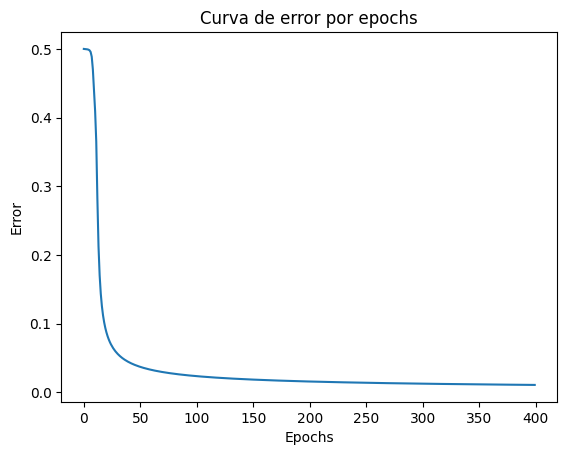

In [18]:
plt.plot(error_list)
plt.title('Curva de error por epochs')
plt.xlabel('Epochs')
plt.ylabel('Error')
plt.show()

Podemos ver que hay una mejora drastica en las primeras iteraciones (en particular el rango de 0-50 epochs) seguido de una leve tendencia a cero, esto es esperable para un modelo tan sencillo. Sin embargo, a medida que incrementamos la cantidad de capas intermedias, vamos a requerir más iteraciones para obtener niveles aceptables de precisión. 